In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [33]:
df=pd.read_csv(r'/Users/anirudhiyer/Desktop/Stress Prediction/Minor-Project/Datasets/Final_processed.csv')

In [34]:
df.head()

,Unnamed: 0,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,2,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,3,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,4,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,1
4,5,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0


In [35]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [36]:
df.head()

,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,0.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,1.0,...,0,0,0,1.0,0,1.0,1,0,1,1
4,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0


### K-Means Clustering

In [37]:
labels=df['final_label']
X=df.drop(columns=['final_label'])

In [38]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [39]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

In [40]:
def evaluate_kmeans(k, X_scaled, true_labels):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, clusters)
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil_score, ari, nmi, clusters

In [41]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

In [42]:
clusters = kmeans.fit_predict(X_scaled)

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [43]:
silhouette_score(X_scaled, clusters)

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.04350756386933463

In [44]:
adjusted_rand_score(labels, clusters)

0.268328138705178

In [45]:
normalized_mutual_info_score(labels, clusters)

0.3697307307638014

In [46]:
def evaluate_kmeans(k, X_scaled, true_labels):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, clusters)
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil_score, ari, nmi, clusters


results = {}

for k in [2, 3]:
    sil, ari, nmi, clusters = evaluate_kmeans(k, X_scaled, labels)
    
    results[k] = {
        "Silhouette Score": sil,
        "ARI": ari,
        "NMI": nmi
    }
    
    print(f"\nResults for K = {k}")
    print(f"Silhouette Score : {sil}")
    print(f"Adjusted Rand Index (ARI): {ari}")
    print(f"Normalized Mutual Info (NMI): {nmi}")



Results for K = 2
Silhouette Score : 0.15988487991897823
Adjusted Rand Index (ARI): 0.4911324820956801
Normalized Mutual Info (NMI): 0.4581166043459329

Results for K = 3
Silhouette Score : 0.11688040661940971
Adjusted Rand Index (ARI): 0.5224415208491576
Normalized Mutual Info (NMI): 0.43812627425601447


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

### Conclusions:
1. The moderate ARI (~0.52) shows partial agreement, meaning clustering captures meaningful patterns but not exactly the scoring system — highlighting limitations of rule-based categorization.

2. K-Means clustering with K=2 produced better-separated clusters as indicated by higher silhouette scores, whereas K=3 showed slightly better alignment with predefined labels. This suggests that while traditional scoring divides individuals into three categories, the underlying data structure may represent fewer, more cohesive groups, indicating overlap in intermediate psychological states.

In [47]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

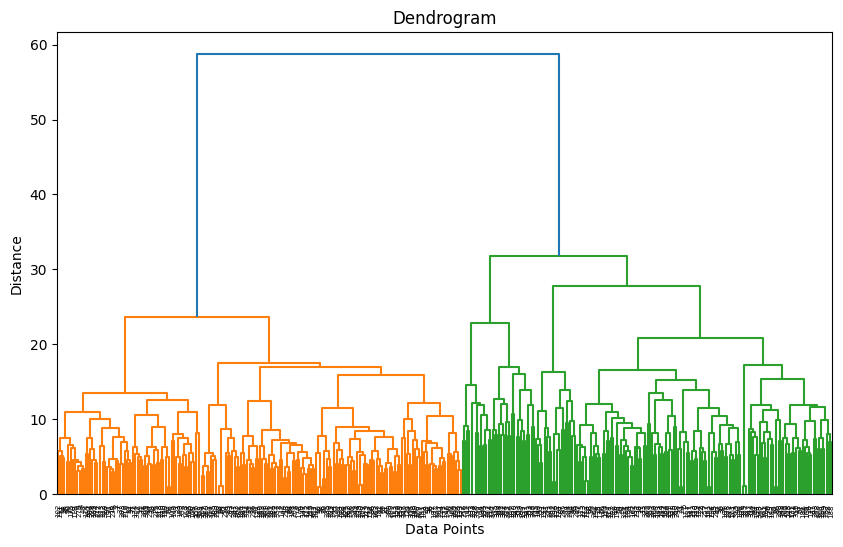

In [48]:
plt.figure(figsize=(10, 6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [49]:
def evaluate_hierarchical(k, X_scaled, true_labels):
    
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    clusters = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, clusters)
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil, ari, nmi, clusters

In [50]:
for k in [2, 3]:
    sil, ari, nmi, clusters = evaluate_hierarchical(k, X_scaled, labels)
    
    print(f"\nHierarchical Results for K = {k}")
    print(f"Silhouette Score : {sil}")
    print(f"Adjusted Rand Index (ARI): {ari}")
    print(f"Normalized Mutual Info (NMI): {nmi}")


Hierarchical Results for K = 2
Silhouette Score : 0.1371406698498609
Adjusted Rand Index (ARI): 0.40917218247365483
Normalized Mutual Info (NMI): 0.3733766135599923

Hierarchical Results for K = 3
Silhouette Score : 0.12437557359514656
Adjusted Rand Index (ARI): 0.3888641872797644
Normalized Mutual Info (NMI): 0.33280808643040527


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

### Conclusions:

1. Hierarchical clustering revealed two dominant groups in the dataset, suggesting that individuals tend to cluster into broader categories of psychological states rather than distinct three-level classifications.